In [1]:
from warnings import filterwarnings
import random

import torch.cuda as cuda

import sys
sys.path.append('../')

from scformer.model import *
from scformer.utils import *

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
from scformer.utils import (
    compute_ilisi,
    compute_ari,
    compute_nmi,
    compute_nn_entropy,
    compute_silhouette_score,
    compute_calinski_harabasz_score,
    compute_davies_bouldin_score,
)

## 训练使用真实标签

In [3]:
output_dir = '../output/pbmc_benchmark_data_with_true_label/'
adata = sc.read_h5ad(output_dir + 'adata_train.h5ad')

In [4]:
node_ids = np.load(output_dir + "/Node_Ids.npy")
cell_emb = np.load(output_dir + "/cell_embedding.npy")
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm["cell_emb"] = cell_emb_sorted.values

In [5]:
pred = np.load(output_dir + '/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

In [4]:
adata.var_names_make_unique()

In [6]:

# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata, use_rep="cell_emb")
sc.tl.umap(adata, random_state=seed)

In [ ]:
sc.pl.umap(adata, color=['pre', 'Annotation', 'batch'], show=True)

In [ ]:
# Load example single-cell data after batch correction
# Assuming the data is saved in a CSV file where each row is a cell and each column is a gene/feature
corrected_data = adata.obsm['cell_emb']
# Load batch labels, assuming they are stored in a separate CSV file or in the same dataframe
labels = adata.obs['batch']

# # Compute LISI
# lisi_scores = compute_lisi(corrected_data, labels, k=30)
# print(lisi_scores)
# 
# # Optionally, visualize the distribution of LISI scores
# import matplotlib.pyplot as plt
# 
# plt.hist(lisi_scores, bins=20, edgecolor='black')
# plt.xlabel('LISI Score')
# plt.ylabel('Frequency')
# plt.title('Distribution of LISI Scores after Batch Correction')
# plt.show()
ilisi_score = compute_ilisi(corrected_data, labels)
nmi_score = compute_nmi(adata.obs['Annotation'], adata.obs['pre'])
ari_score = compute_ari(adata.obs['Annotation'], adata.obs['pre'])
nn_entropy_scores = compute_nn_entropy(corrected_data, labels, k=30)
print(ilisi_score, nmi_score, ari_score, nn_entropy_scores)

In [ ]:
sc_score = compute_silhouette_score(corrected_data, adata.obs['pre'])
ch_score = compute_calinski_harabasz_score(corrected_data, adata.obs['pre'])
db_score = compute_davies_bouldin_score(corrected_data, adata.obs['pre'])
sc_score, ch_score, db_score

In [11]:
annotation_to_num = {ann: idx for idx, ann in enumerate(adata.obs['Annotation'].unique())}
# Create a new column with numerical labels
adata.obs['Annotation_num'] = adata.obs['Annotation'].map(annotation_to_num)

In [ ]:
from sklearn.metrics import f1_score

# 提取真实标签和预测结果
true_labels = adata.obs['Annotation_num']
pred_labels = adata.obs['pre']

# 计算每类细胞的比例
cell_counts = true_labels.value_counts(normalize=True)

# 筛选 5%-1% 和 <1% 的细胞类别
rare_5_1 = cell_counts[(cell_counts <= 0.05) & (cell_counts > 0.01)].index
rare_below_1 = cell_counts[cell_counts <= 0.01].index

# 定义一个函数计算 F1 分数
def calculate_f1_for_classes(true_labels, pred_labels, target_classes):
    mask = true_labels.isin(target_classes)
    true_subset = true_labels[mask]
    pred_subset = pred_labels[mask]
    return f1_score(true_subset, pred_subset, average='weighted')

# 计算两个区间的 F1 分数
f1_5_1 = calculate_f1_for_classes(true_labels, pred_labels, rare_5_1)
f1_below_1 = calculate_f1_for_classes(true_labels, pred_labels, rare_below_1)

# 输出结果
print(f"F1 Score for 5%-1% rare cells: {f1_5_1}")
print(f"F1 Score for <1% rare cells: {f1_below_1}")


In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# sc.pp.scale(adata, max_value=10)
# sc.tl.pca(adata, svd_solver='arpack')

# sc.pp.neighbors(adata, use_rep='X_pca', n_neighbors=10)
# sc.tl.umap(adata=adata, random_state=seed)

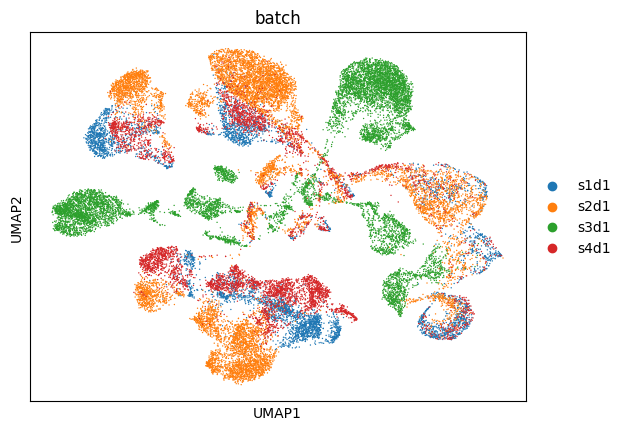

In [17]:
sc.pl.umap(adata=adata, color=['batch'])

## mnn的用法

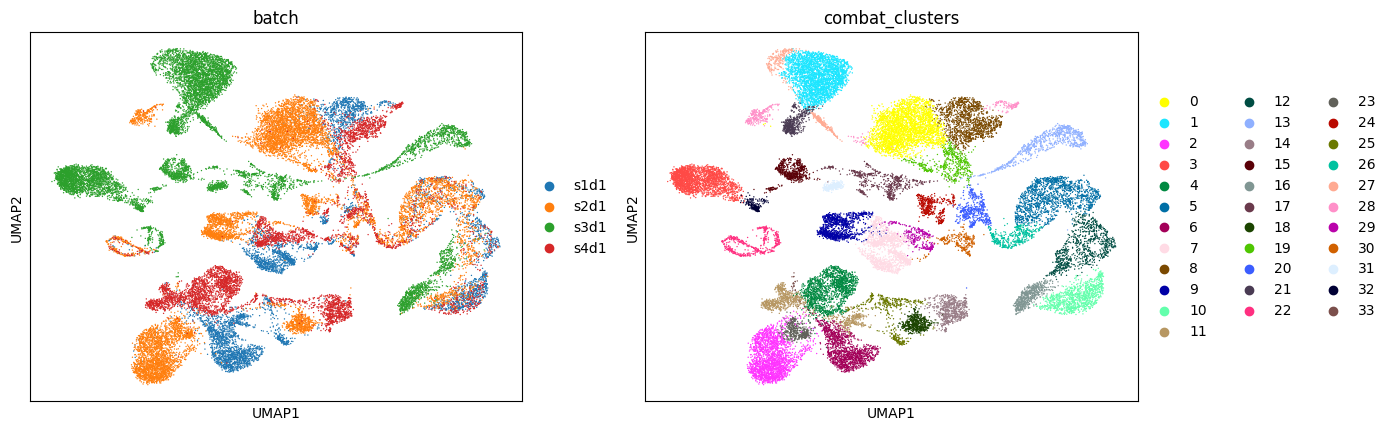

In [6]:
a,b,c = sc.external.pp.mnn_correct(adata, batch_key='batch')
adata = a[0]
sc.tl.pca(adata, svd_solver='arpack')  # svd_solver 可选 'arpack', 'randomized', 'auto'
# 使用 PCA 的低维结果构建邻居图
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# UMAP 降维和 Leiden 聚类
sc.tl.umap(adata, random_state=seed)  # 设置随机种子
sc.tl.leiden(adata, key_added='combat_clusters')  # 聚类分析

# 可视化校正结果
sc.pl.umap(adata, color=['batch', 'combat_clusters'])

In [7]:
ilisi_score = compute_ilisi(adata.obsm['X_pca'], adata.obs['batch'])
nmi_score = compute_nmi(adata.obs['Annotation'], adata.obs['combat_clusters'])
ari_score = compute_ari(adata.obs['Annotation'], adata.obs['combat_clusters'])
nn_entropy_scores = compute_nn_entropy(adata.obsm['X_pca'], adata.obs['batch'], k=30)
print(ilisi_score, nmi_score, ari_score, nn_entropy_scores)

1.1782914698359988 0.6830487165987469 0.3994099836057338 0.16768055031450166


In [8]:
sc_score = compute_silhouette_score(adata.obsm['X_pca'], adata.obs['combat_clusters'])
ch_score = compute_calinski_harabasz_score(adata.obsm['X_pca'], adata.obs['combat_clusters'])
db_score = compute_davies_bouldin_score(adata.obsm['X_pca'], adata.obs['combat_clusters'])
sc_score, ch_score, db_score

(0.18850984, 3755.9858477206017, 1.6212941836941588)

# Combat的用法

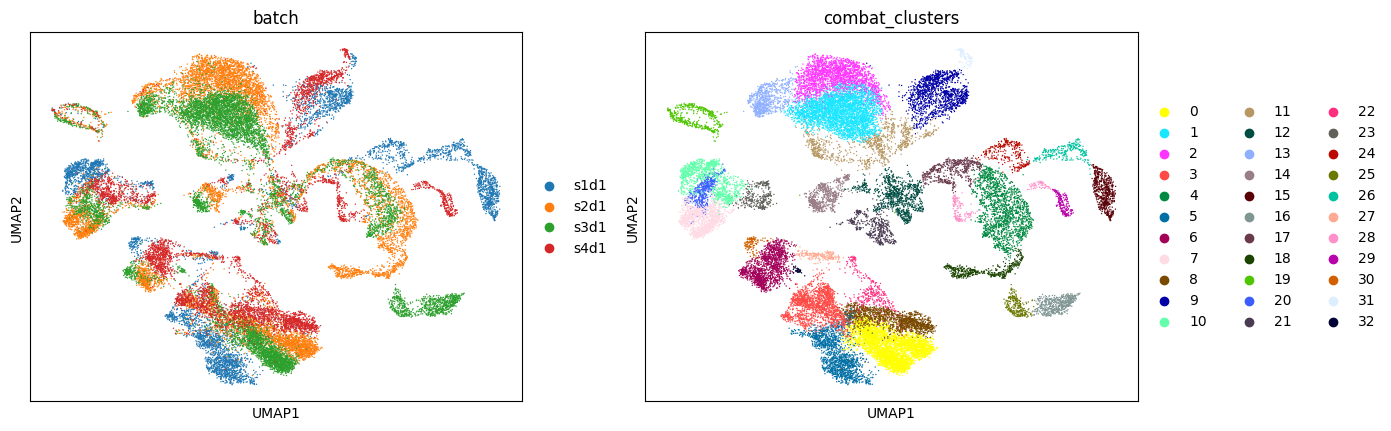

In [6]:
sc.pp.combat(adata=adata, key='batch')
sc.tl.pca(adata, svd_solver='arpack')  # svd_solver 可选 'arpack', 'randomized', 'auto'

# 使用 PCA 的低维结果构建邻居图
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# UMAP 降维和 Leiden 聚类
sc.tl.umap(adata, random_state=seed)  # 设置随机种子
sc.tl.leiden(adata, key_added='combat_clusters')  # 聚类分析

# 可视化校正结果
sc.pl.umap(adata, color=['batch', 'combat_clusters'])

In [9]:
ilisi_score = compute_ilisi(adata.obsm['X_pca'], adata.obs['batch'])
nmi_score = compute_nmi(adata.obs['Annotation'], adata.obs['combat_clusters'])
ari_score = compute_ari(adata.obs['Annotation'], adata.obs['combat_clusters'])
nn_entropy_scores = compute_nn_entropy(adata.obsm['X_pca'], adata.obs['batch'], k=30)
print(ilisi_score, nmi_score, ari_score, nn_entropy_scores)

1.4383724369879627 0.7123102713759527 0.4428977979552931 0.38864918094385015


In [10]:
sc_score = compute_silhouette_score(adata.obsm['X_pca'], adata.obs['combat_clusters'])
ch_score = compute_calinski_harabasz_score(adata.obsm['X_pca'], adata.obs['combat_clusters'])
db_score = compute_davies_bouldin_score(adata.obsm['X_pca'], adata.obs['combat_clusters'])
sc_score, ch_score, db_score

(0.14123555, 3555.6516143626677, 1.8893677602967542)

# bbknn的用法

In [ ]:
sc.external.pp.bbknn(adata=adata, batch_key='batch')
sc.tl.umap(adata=adata, random_state=seed)
sc.tl.leiden(adata=adata, key_added='BBKNN')

In [ ]:
sc.pl.umap(adata=adata, color=['batch', 'BBKNN'])

In [ ]:
ilisi_score = compute_ilisi(adata.obsm['X_pca'], labels)
nmi_score = compute_nmi(adata.obs['Annotation'], adata.obs['BBKNN'])
ari_score = compute_ari(adata.obs['Annotation'], adata.obs['BBKNN'])
nn_entropy_scores = compute_nn_entropy(adata.obsm['X_pca'], labels, k=30)
print(ilisi_score, nmi_score, ari_score, nn_entropy_scores)

In [ ]:
sc_score = compute_silhouette_score(adata.obsm['X_pca'], adata.obs['BBKNN'])
ch_score = compute_calinski_harabasz_score(adata.obsm['X_pca'], adata.obs['BBKNN'])
db_score = compute_davies_bouldin_score(adata.obsm['X_pca'], adata.obs['BBKNN'])
sc_score, ch_score, db_score

# harmony的用法

In [ ]:
sc.external.pp.harmony_integrate(adata=adata, key='batch')
sc.pp.neighbors(adata=adata, use_rep='X_pca_harmony', n_neighbors=10)
sc.tl.umap(adata=adata, random_state=seed)
sc.tl.leiden(adata=adata, key_added='harmony')

In [ ]:
sc.pl.umap(adata=adata, color=['batch', 'harmony'])

In [ ]:
ilisi_score = compute_ilisi(adata.obsm['X_pca_harmony'], labels)
nmi_score = compute_nmi(adata.obs['Annotation'], adata.obs['harmony'])
ari_score = compute_ari(adata.obs['Annotation'], adata.obs['harmony'])
nn_entropy_scores = compute_nn_entropy(adata.obsm['X_pca_harmony'], labels, k=30)
print(ilisi_score, nmi_score, ari_score, nn_entropy_scores)

In [ ]:
sc_score = compute_silhouette_score(adata.obsm['X_pca_harmony'], adata.obs['harmony'])
ch_score = compute_calinski_harabasz_score(adata.obsm['X_pca_harmony'], adata.obs['harmony'])
db_score = compute_davies_bouldin_score(adata.obsm['X_pca_harmony'], adata.obs['harmony'])
sc_score, ch_score, db_score

## 不使用真实标签的情况

In [ ]:
output_dir = '../output/pbmc_benchmark_data_without_true_label/'
adata = sc.read_h5ad(output_dir + 'adata_train.h5ad')
adata

In [ ]:
node_ids = np.load(output_dir + "/Node_Ids.npy")
cell_emb = np.load(output_dir + "/cell_embedding.npy")
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm["cell_emb"] = cell_emb_sorted.values
adata

In [21]:
pred = np.load(output_dir + '/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

In [22]:
adata.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata, use_rep="cell_emb")
sc.tl.umap(adata, random_state=seed)

In [ ]:
sc.pl.umap(adata, color=['pre', 'Annotation', 'batch'], show=True)

In [25]:
annotation_to_num = {ann: idx for idx, ann in enumerate(adata.obs['Annotation'].unique())}
# Create a new column with numerical labels
adata.obs['Annotation_num'] = adata.obs['Annotation'].map(annotation_to_num)

In [ ]:
from sklearn.metrics import f1_score

# 提取真实标签和预测结果
true_labels = adata.obs['Annotation_num']
pred_labels = adata.obs['pre']

# 计算每类细胞的比例
cell_counts = true_labels.value_counts(normalize=True)

# 筛选 5%-1% 和 <1% 的细胞类别
rare_5_1 = cell_counts[(cell_counts <= 0.05) & (cell_counts > 0.01)].index
rare_below_1 = cell_counts[cell_counts <= 0.01].index

# 定义一个函数计算 F1 分数
def calculate_f1_for_classes(true_labels, pred_labels, target_classes):
    mask = true_labels.isin(target_classes)
    true_subset = true_labels[mask]
    pred_subset = pred_labels[mask]
    return f1_score(true_subset, pred_subset, average='weighted')

# 计算两个区间的 F1 分数
f1_5_1 = calculate_f1_for_classes(true_labels, pred_labels, rare_5_1)
f1_below_1 = calculate_f1_for_classes(true_labels, pred_labels, rare_below_1)

# 输出结果
print(f"F1 Score for 5%-1% rare cells: {f1_5_1}")
print(f"F1 Score for <1% rare cells: {f1_below_1}")

In [ ]:
adata = sc.read_h5ad('../output/pbmc_benchmark_data/pbmc_benchmark_s1d1.h5ad')
adata

In [ ]:
node_ids = np.load('../output/pbmc_benchmark_data/Node_Ids.npy')
cell_emb = np.load('../output/pbmc_benchmark_data/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm["cell_emb"] = cell_emb_sorted.values
adata

In [30]:
pred = np.load('../output/pbmc_benchmark_data/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

In [31]:
adata.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata, use_rep="cell_emb")
sc.tl.umap(adata, random_state=seed)

In [ ]:
sc.pl.umap(adata, color=['pre', 'Annotation'], show=True)

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

# 1. 计算每种类型的细胞数量和比例
cell_types = adata.obs['Annotation']
cell_type_counts = cell_types.value_counts()
cell_type_proportions = cell_type_counts / cell_type_counts.sum()

# 2. 筛选目标细胞类型
target_cell_types_1_5 = cell_type_proportions[
    (cell_type_proportions > 0.01) & (cell_type_proportions < 0.05)
].index.tolist()

target_cell_types_below_1 = cell_type_proportions[
    cell_type_proportions < 0.01
].index.tolist()

print("5%-1% 稀有细胞类型：", target_cell_types_1_5)
print("<1% 稀有细胞类型：", target_cell_types_below_1)

# 3. 标记稀有细胞的真实标签
adata.obs['Target_1_5'] = adata.obs['Annotation'].isin(target_cell_types_1_5)
adata.obs['Target_below_1'] = adata.obs['Annotation'].isin(target_cell_types_below_1)

# 转换为二值标签
adata.obs['Target_str_1_5'] = adata.obs['Target_1_5'].map({True: 'Target', False: 'Non-Target'})
adata.obs['Target_str_below_1'] = adata.obs['Target_below_1'].map({True: 'Target', False: 'Non-Target'})

# 4. 计算每个簇的比例
pre_labels = adata.obs['pre']
cluster_counts = pre_labels.value_counts(normalize=True)  # 计算簇比例

# 筛选稀有簇
rare_clusters_1_5 = cluster_counts[
    (cluster_counts >= 0.01) & (cluster_counts < 0.05)
].index.tolist()

rare_clusters_below_1 = cluster_counts[
    cluster_counts < 0.01
].index.tolist()

# 5. 标记预测稀有细胞
adata.obs['predicted_rare_1_5'] = pre_labels.apply(lambda x: 1 if x in rare_clusters_1_5 else 0)
adata.obs['predicted_rare_below_1'] = pre_labels.apply(lambda x: 1 if x in rare_clusters_below_1 else 0)

# 6. 提取真实标签和预测标签
true_labels_1_5 = np.where(adata.obs['Target_str_1_5'] == 'Target', 1, 0)
predicted_labels_1_5 = adata.obs['predicted_rare_1_5']

true_labels_below_1 = np.where(adata.obs['Target_str_below_1'] == 'Target', 1, 0)
predicted_labels_below_1 = adata.obs['predicted_rare_below_1']

# 7. 计算 F1 值
f1_1_5 = f1_score(true_labels_1_5, predicted_labels_1_5)
f1_below_1 = f1_score(true_labels_below_1, predicted_labels_below_1)

print("F1 Score for 5%-1% Rare Cells:", f1_1_5)
print("F1 Score for <1% Rare Cells:", f1_below_1)

# 8. 输出分类报告
report_1_5 = classification_report(true_labels_1_5, predicted_labels_1_5, target_names=['Non-Target', 'Target'])
report_below_1 = classification_report(true_labels_below_1, predicted_labels_below_1, target_names=['Non-Target', 'Target'])

print("\nClassification Report for 5%-1% Rare Cells:\n", report_1_5)
print("\nClassification Report for <1% Rare Cells:\n", report_below_1)


In [ ]:
adata.obs['rare_1_5_umap'] = adata.obs['Annotation'].apply(
    lambda x: '5%-1%' if x in target_cell_types_1_5 else 'Other'
)

# 2. 在 adata.obs 中标记 <1% 的稀有细胞
adata.obs['rare_below_1_umap'] = adata.obs['Annotation'].apply(
    lambda x: '<1%' if x in target_cell_types_below_1 else 'Other'
)

sc.pl.umap(adata, color=['rare_1_5_umap', 'rare_below_1_umap'], show=True)
